# Polyhedral Grid Schemes Exploration

This notebook acts as the base for the comparison of the following polyhedral grids

- Tetrahedral
- Octahedral
- Icosahedral

Unlike the DH, MW and GL grids from the previous notebook, polyhedral grids are not formatted in the structured geometry required by the algorithm used by `s2fft`. Thus, in this notebook, we conduct the forward and inverse transforms via numerical computation.

In order to generate the point locations of this grid, we use the `meshzoo` library ([Documentation](https://github.com/meshpro/meshzoo)). This library provides the functions `tetra_sphere(n)` `octa_sphere(n)` and `icosa_sphere(n)`where `n` is the refinement parameter for the given polyhedron. The function generates points from the vertices (when `n=1`) and from subdivides faces (when `n>1`) projected on the sphere surface.

The goal of this notebook is similar to that of the classical grids:
1. Generate a ground-truth signal with a set bandlimit of L.
2. Compute the refinement level needed for each scheme for an examplke of an undersampled, critical and oversampled grid.
3. Conduct the inverse SHT to get coefficients.
4. Compute the reconstructed signal using the coefficients.
5. Compare and investigate errors.

**Note on notation:** This notebook uses $L$ for the spherical harmonic bandlimit. In `s2fft`, a bandlimit of $L$ includes degrees $\ell = 0, 1, \dots, L-1$.

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec

import pandas as pd

import jax
jax.config.update("jax_enable_x64", True)

import s2fft
from s2fft.utils import signal_generator
from s2fft.sampling import s2_samples

from scipy.special import sph_harm_y

import meshzoo

## Generating Ground-Truth Signal

Similar to the classical grids, we generate the ground-truth signal using s2fft. We use L = 16 (degrees of 0 to 15).

In [2]:
L = 16
seed = 42

rng = np.random.default_rng(seed)
flm_true = signal_generator.generate_flm(rng, L, reality=False)
print("flm_true shape:", flm_true.shape, "dtype:", flm_true.dtype)

flm_true shape: (16, 31) dtype: complex128


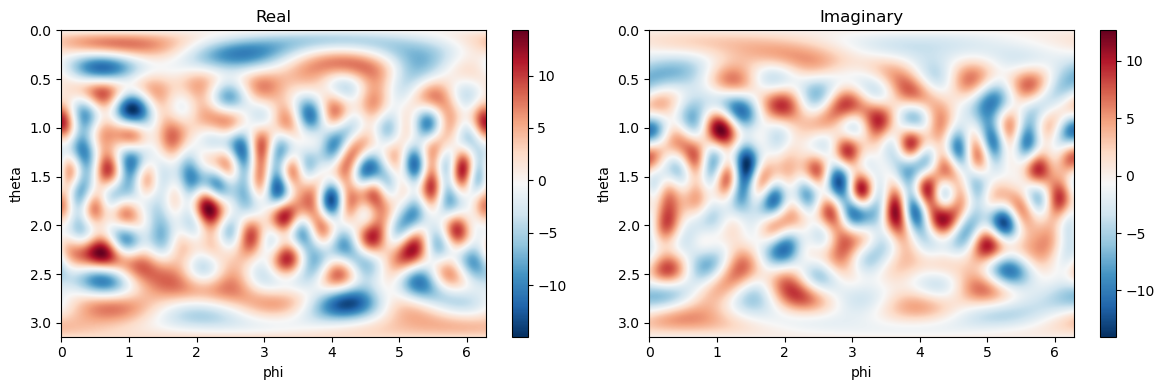

In [3]:
def zero_pad_coefficients(flm, L_from, L_to):
    """
    Used when the sampling grid has a higher bandlimit capacity than the actual bandlimit (oversampled grids)
    Sets the "added" coefficients to 0.
    """
    # Convert from 2D (l, m) coefficients to 1D
    flm_1d = s2_samples.flm_2d_to_1d(flm, L_from)
    # Create an array of zeros with size of no. of coeffs of the larger grid                      
    flm_1d_padded = np.zeros(s2_samples.ncoeff(L_to), dtype=flm.dtype)
    # Add back the original coefficients 
    flm_1d_padded[: s2_samples.ncoeff(L_from)] = flm_1d
    # Convert back from 1D to 2D
    flm_2d = s2_samples.flm_1d_to_2d(flm_1d_padded, L_to)            
    return flm_2d   

def get_grid(L, sampling):
    """
    Returns the sampling points for a given sampling scheme
    Reference: https://astro-informatics.github.io/s2fft/api/sampling/spherical_samples.html
    """
    thetas = s2_samples.thetas(L, sampling=sampling)
    phis = s2_samples.phis_equiang(L, sampling=sampling)
    return thetas, phis

def inverse_sht(flm, L_actual, L_grid, sampling):
    """
    Compute the inverse SHT. Returns function values at every point on the grid

    When L_grid >= L_actual: Use the provided s2fft function
    When L_grid < L_actual (undersampled):  Use direct synthesis
    """

    if L_grid >= L_actual:
        flm_padded = zero_pad_coefficients(flm, L_actual, L_grid)
        return s2fft.inverse(flm_padded, L_grid, sampling=sampling, method="numpy", reality=False)
        
    else:
        # Get points on the sampling grid
        thetas, phis = get_grid(L_grid, sampling)

        # Flatten the coefficients to 1D
        coeffs = s2_samples.flm_2d_to_1d(flm, L_actual)

        # Builds the array of l and m pairs.
        # E.g. for L_actual = 16
        # ls = [0,  1, 1, 1,  2, ..., 15, 15]
        # ms = [0, -1, 0, 1, -2, ..., 14, 15]
        ls = np.concatenate([np.full(2 * l + 1, l) for l in range(L_actual)])
        ms = np.concatenate([np.arange(-l, l + 1)  for l in range(L_actual)])

        # Create the theta-phi grid
        TH, PH = np.meshgrid(thetas, phis, indexing="ij")

        # Get the spherical harmonics for every theta-phi pair for each harmonic mode.
        Y = sph_harm_y(ls, ms, TH[..., None], PH[..., None])

        # Get the values of the function at every grid point
        return Y @ coeffs

L_dense = 256
f_dense = inverse_sht(flm_true, L, L_dense, 'dh')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in zip(axes, [f_dense.real, f_dense.imag], ["Real", "Imaginary"]):
    im = ax.imshow(data, extent=[0, 2 * np.pi, np.pi, 0], aspect="auto", cmap="RdBu_r")
    ax.set_title(f"{title}")
    ax.set_xlabel("phi")
    ax.set_ylabel("theta")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Getting the number of points per meshzoo refinement `n`

We plot the number of points generated per refinement level on `meshzoo` to determine the cases that we will use to evaluate the spherical sampling process.

In [4]:
MESH_BUILDERS = {
    "icosa": meshzoo.icosa_sphere,
    "octa":  meshzoo.octa_sphere,
    "tetra": meshzoo.tetra_sphere,
}

def get_mesh_points(builder, n):
    points, _cells = builder(n)
    return points

for mesh_name, builder in MESH_BUILDERS.items():
    counts = [get_mesh_points(builder, n).shape[0] for n in list(range(1, 21))]
    print(f"{mesh_name}: n_points = {counts}")

icosa: n_points = [12, 42, 92, 162, 252, 362, 492, 642, 812, 1002, 1212, 1442, 1692, 1962, 2252, 2562, 2892, 3242, 3612, 4002]
octa: n_points = [6, 18, 38, 66, 102, 146, 198, 258, 326, 402, 486, 578, 678, 786, 902, 1026, 1158, 1298, 1446, 1602]
tetra: n_points = [4, 10, 20, 34, 52, 74, 100, 130, 164, 202, 244, 290, 340, 394, 452, 514, 580, 650, 724, 802]


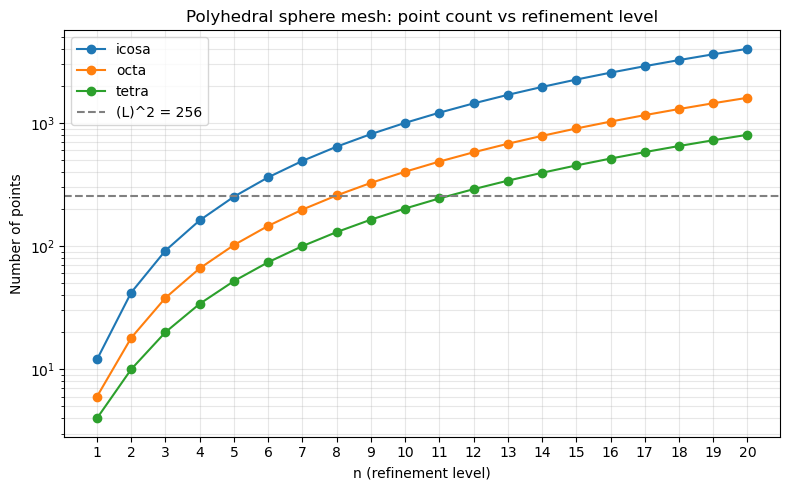

In [5]:
n_cases = list(range(1, 21))

fig, ax = plt.subplots(figsize=(8, 5))

for mesh_name, builder in MESH_BUILDERS.items():
    counts = [get_mesh_points(builder, n).shape[0] for n in n_cases]
    ax.plot(n_cases, counts, marker='o', label=mesh_name)

ax.axhline((L) ** 2, ls='--', color='gray',
           label=f'(L)^2 = {(L) ** 2}')

ax.set_xlabel('n (refinement level)')
ax.set_ylabel('Number of points')
ax.set_yscale('log')
ax.set_xticks(n_cases)
ax.set_title('Polyhedral sphere mesh: point count vs refinement level')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

For the critical scheme, we choose the **first refinement level that exceeds the theoretical number of sampling points** needed to accurately reconstruct the spherical function. We also use the refinement **2 levels above and below** that number to represent the oversampled and undersampled schemes respectively. Cases are as follows:

In [6]:
MESHES = {
    "tetrahedral" :  {
        "builder" : meshzoo.tetra_sphere,
        "n_cases" : [10, 12, 14]
            },
    "octahedral" :  {
        "builder" : meshzoo.octa_sphere,
        "n_cases" : [7, 9, 11]
            },
    "icosahedral" : {
        "builder" : meshzoo.icosa_sphere,
        "n_cases" : [4, 6, 8]
            }
}

## Visualising Meshes

Plotting these points to visualise the meshes:

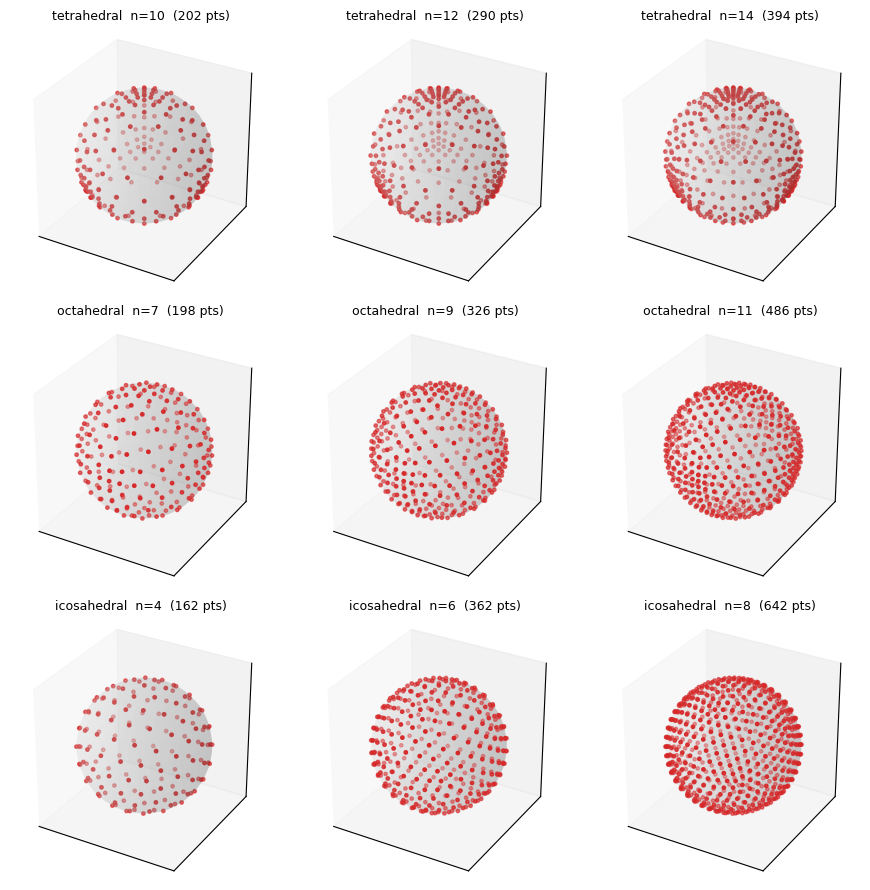

In [7]:
fig = plt.figure(figsize=(9, 3 * len(MESHES)))
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
sx, sy, sz = np.cos(u) * np.sin(v), np.sin(u) * np.sin(v), np.cos(v)

for i, (mesh_name, cfg) in enumerate(MESHES.items()):
    builder = cfg["builder"]
    for j, n in enumerate(cfg["n_cases"]):
        Q = get_mesh_points(builder, n)
        ax = fig.add_subplot(len(MESHES), 3, i * 3 + j + 1, projection="3d")
        ax.plot_surface(sx, sy, sz, color="lightgray", alpha=0.15, linewidth=0)
        ax.scatter(Q[:, 0], Q[:, 1], Q[:, 2], c="C3", s=6, depthshade=True)
        ax.set_title(f"{mesh_name}  n={n}  ({Q.shape[0]} pts)", fontsize=9)
        ax.set_box_aspect([1, 1, 1])
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

plt.tight_layout()
plt.show()

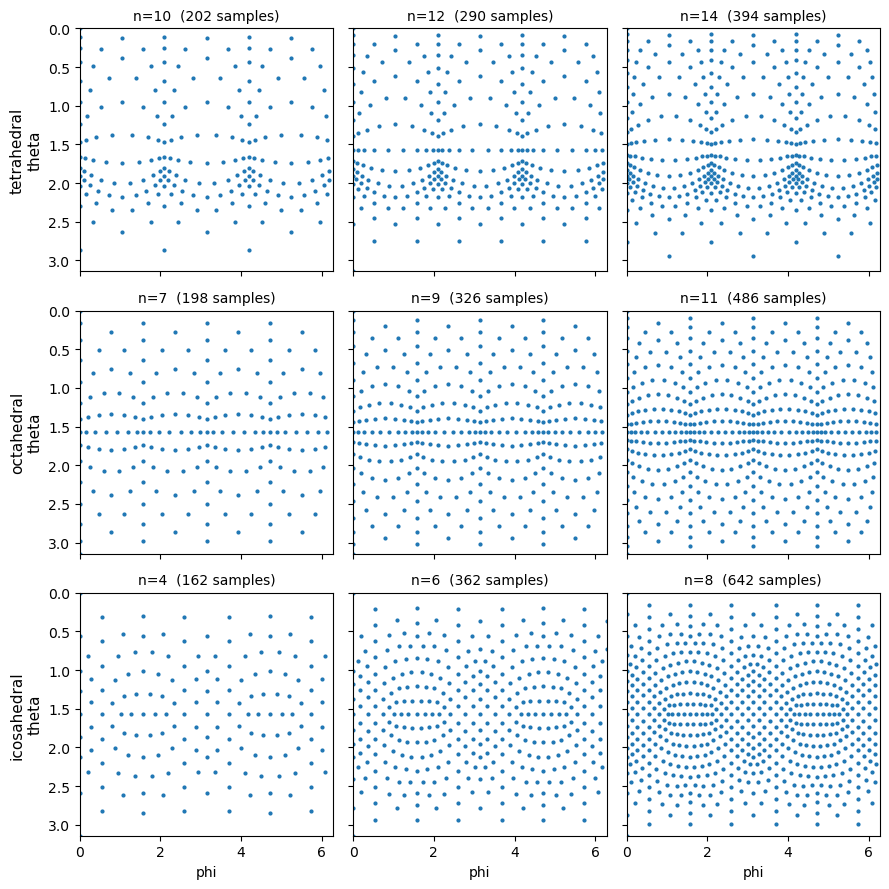

In [8]:
def cartesian_to_theta_phi(Q):
    x, y, z = Q[:, 0], Q[:, 1], Q[:, 2]
    theta = np.arccos(np.clip(z, -1.0, 1.0))
    phi = np.mod(np.arctan2(y, x), 2 * np.pi)
    return theta, phi

fig, axes = plt.subplots(
    len(MESHES), 3,
    figsize=(9, 3 * len(MESHES)),
    sharex=True, sharey=True,
)

for i, (mesh_name, cfg) in enumerate(MESHES.items()):
    builder = cfg["builder"]
    for j, n in enumerate(cfg["n_cases"]):
        ax = axes[i, j]
        Q = get_mesh_points(builder, n)

        theta, phi = cartesian_to_theta_phi(Q)

        ax.scatter(phi, theta, s=4)
        ax.set_xlim(0, 2 * np.pi)
        ax.set_ylim(np.pi, 0)
        ax.set_title(f"n={n}  ({Q.shape[0]} samples)", fontsize=10)

        if i == len(MESHES) - 1:
            ax.set_xlabel("phi")

    axes[i, 0].set_ylabel(f"{mesh_name}\ntheta", fontsize=11)

plt.tight_layout()
plt.show()

We can see that the poles are not too sampled heavily as compared to the classical grids.

## Helper Functions

In [9]:
def build_Y_matrix(thetas, phis, L):
    """Builds the SH matrix Y for the given theta-phi pairs"""
    ls = np.concatenate([np.full(2 * l + 1, l) for l in range(L)])
    ms = np.concatenate([np.arange(-l, l + 1)  for l in range(L)])
    TH = thetas[:, None]
    PH = phis[:, None]
    return sph_harm_y(ls, ms, TH, PH)

def direct_sh_synthesis_points(flm_2d, L, thetas, phis):
    """Evaluate a bandlimit-L signal at arbitrary (theta, phi) points."""
    Y = build_Y_matrix(thetas, phis, L)
    flm_1d = s2_samples.flm_2d_to_1d(flm_2d, L)
    return Y @ flm_1d

def compute_relative_l2_error(a, b):
    """
    Returns the relative L2 error between two arrays.
    """
    return np.linalg.norm((a - b)) / np.linalg.norm(a)

def per_degree_coeff_error(flm_true_p, flm_rec_p):
    """
    Computes the relative error per l in L
    """
    L_max = flm_true_p.shape[0]
    errors = np.zeros(L_max)
    for l in range(L_max):
        num = np.linalg.norm(flm_true_p[l] - flm_rec_p[l])
        den = np.linalg.norm(flm_true_p[l])
        errors[l] = num / den if den > 0 else num
    return errors

def compute_error_per_mode(flm_true_p, flm_rec_p):
    """
    Computes the absolute error for each coefficient mode (l, m)
    Returns with the 2D format with m out of l range set to NaN for plotting
    """
    L = flm_true_p.shape[0]
    # Start with an array full of NaN values
    errors = np.full(flm_true_p.shape, np.nan)
    # Go through each l value
    for l in range(L):
        # Go through each m value for this l
        for m in range(-l, l + 1):
            # Convert m to the correct column index
            col = m + (L - 1)
            # Compute the absolute error for this coefficient
            errors[l, col] = np.abs(flm_true_p[l, col] - flm_rec_p[l, col])
    return errors

## Main experiment loop

This section covers the main experiment pipeline.

For every case in every sampling scheme, we:
1. Get the values of the ground-truth function on the sampling points.
2. Conduct the forward SHT to get the SHT coefficients.
3. Reconstruct the function based on the calculated coefficients.
4. Calculate the function and coefficient errors and grid conditioning. 

In [10]:
results = []
for mesh_name, cfg in MESHES.items():
    builder = cfg["builder"]
    for n in cfg["n_cases"]:

        ## Get the coordinates of the points
        Q = get_mesh_points(builder, n)
        thetas, phis = cartesian_to_theta_phi(Q)
        n_points = Q.shape[0]

        ## Get the function values at the points using the ground-truth SH coefficients
        f_true = direct_sh_synthesis_points(flm_true, L, thetas, phis)

        ## Recover the coefficients
        Y = build_Y_matrix(thetas, phis, L)
        ## flm = Y(inverse) @ f_true
        flm_rec_1d, *_ = np.linalg.lstsq(Y, f_true, rcond=None)
        flm_rec_2d = s2_samples.flm_1d_to_2d(flm_rec_1d, L)

        ## Get the function values at the points using the recovered SH coefficients
        f_recon = Y @ flm_rec_1d

        ## Compute conditioning and errors
        cond_Y    = np.linalg.cond(Y)
        err_func  = compute_relative_l2_error(f_true, f_recon)
        err_coeff = compute_relative_l2_error(flm_true, flm_rec_2d)
        per_deg   = per_degree_coeff_error(flm_true, flm_rec_2d)
        per_mode  = compute_error_per_mode(flm_true, flm_rec_2d)

        results.append({
            "mesh_name": mesh_name,
            "n":         n,
            "n_points":  n_points,
            "n_modes":   L ** 2,
            "cond_Y":    cond_Y,
            "err_func":  err_func,
            "err_coeff": err_coeff,
            "per_degree": per_deg,
            "per_mode":  per_mode,
            "Q":         Q,
            "thetas":    thetas,
            "phis":      phis,
            "f_true":    f_true,
            "f_recon":   f_recon,
        })

## Results

Results are saved to a dataframe for further use.

In [11]:
df = pd.DataFrame(results)

In [12]:
df[['mesh_name', 'n', 'n_points', 'cond_Y']]

,mesh_name,n,n_points,cond_Y
0,tetrahedral,10,202,1356.454779
1,tetrahedral,12,290,1064.720736
2,tetrahedral,14,394,25.840949
3,octahedral,7,198,12.922818
4,octahedral,9,326,3.414596
5,octahedral,11,486,1.903434
6,icosahedral,4,162,2.032783
7,icosahedral,6,362,1.307591
8,icosahedral,8,642,1.272669


## Sampling Errors and Conditioning

Sampling Errors were calculated similar to the classical grids.

Summarizing the errors:

In [13]:
(df.pivot(index='n', columns='mesh_name', values='err_func')
   .style.format('{:.2e}')
   .set_caption('Global Function Error'))

mesh_name,icosahedral,octahedral,tetrahedral
n,,,
4,3.75e-15,nan,nan
6,2.90e-15,nan,nan
7,nan,3.03e-15,nan
8,3.14e-15,nan,nan
9,nan,3.38e-15,nan
10,nan,nan,3.70e-15
11,nan,3.57e-15,nan
12,nan,nan,3.55e-15
14,nan,nan,3.46e-15


At the sample points, all grids (even the undersampled case) rebuilds the function perfectly. This could be attributed to the numerical computation of the coefficients.

In [14]:
(df.pivot(index='n', columns='mesh_name', values='err_coeff')
   .style.format('{:.2e}')
   .set_caption('Global Coefficient Error'))

mesh_name,icosahedral,octahedral,tetrahedral
n,,,
4,5.88e-01,nan,nan
6,2.97e-15,nan,nan
7,nan,4.95e-01,nan
8,3.14e-15,nan,nan
9,nan,3.52e-15,nan
10,nan,nan,4.41e-01
11,nan,3.59e-15,nan
12,nan,nan,1.12e-13
14,nan,nan,7.56e-15


In terms of the coefficients, the undersampled case for all grids show a high error. The coefficients for the critically sampled and oversampled cases are near machine precision for 0, except for the critical case of the tetrahedral grid.

In [15]:
(df.pivot(index='n', columns='mesh_name', values='cond_Y')
   .style.format('{:.2e}')
   .set_caption('Conditioning'))

mesh_name,icosahedral,octahedral,tetrahedral
n,,,
4,2.03e+00,nan,nan
6,1.31e+00,nan,nan
7,nan,1.29e+01,nan
8,1.27e+00,nan,nan
9,nan,3.41e+00,nan
10,nan,nan,1.36e+03
11,nan,1.90e+00,nan
12,nan,nan,1.06e+03
14,nan,nan,2.58e+01


A good conditioning for the Y matrix is close to 1. The icosahedral grid achieves this even for the undersampled case. For the tetrahedral grid, conditioning is ~1000 for even the critically sampled grid, which means we might want to select the refinement level of the mesh a step higher.

## Visualising Absolute Error Per Mode

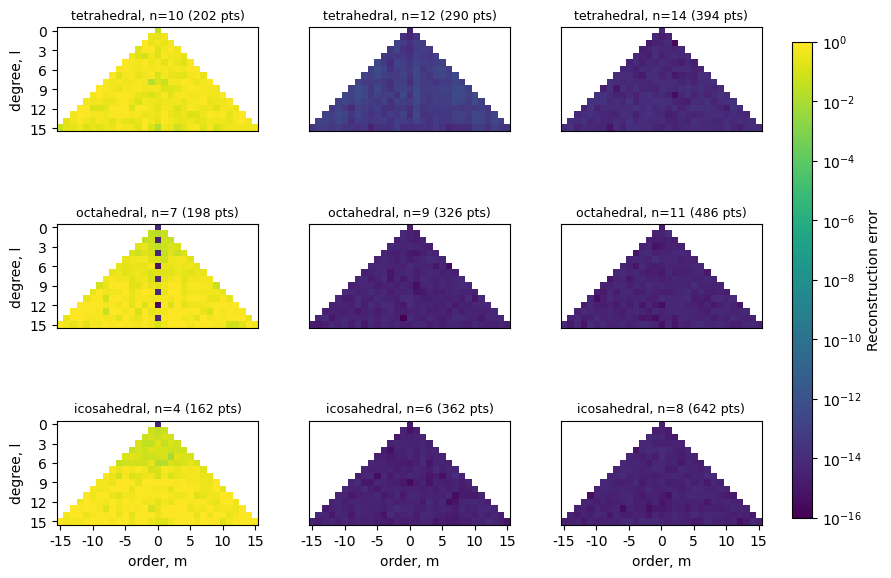

In [16]:
## Generating Plots

# Setting a static range for consistency
VMIN, VMAX = 1e-16, 1e0

schemes = ["tetrahedral", "octahedral", "icosahedral"]
n_cols = max(len(MESHES[m]["n_cases"]) for m in schemes)

fig, axes = plt.subplots(len(schemes), n_cols, figsize=(10, 7))

by_key = {(r["mesh_name"], r["n"]): r for r in results}

for row_i, scheme in enumerate(schemes):
    n_cases = MESHES[scheme]["n_cases"]
    for col_j in range(n_cols):
        ax = axes[row_i, col_j]
        if col_j >= len(n_cases):
            ax.axis("off")
            continue

        n = n_cases[col_j]
        r = by_key[(scheme, n)]
        err_2d = r["per_mode"]
        err_plot = np.where(err_2d < VMIN, VMIN, err_2d)

        im = ax.imshow(
            err_plot, cmap="viridis", interpolation="nearest",
            norm=LogNorm(vmin=VMIN, vmax=VMAX),
        )
        ax.set_title(f"{scheme}, n={n} ({r['n_points']} pts)", fontsize=9)

        L = err_2d.shape[0]
        if row_i == len(schemes) - 1:
            xstep = max(1, (2 * L - 1) // 6)
            xt = np.arange(0, 2 * L - 1, xstep)
            ax.set_xticks(xt); ax.set_xticklabels(xt - (L - 1))
            ax.set_xlabel("order, m")
        else:
            ax.set_xticks([])

        if col_j == 0:
            ystep = max(1, L // 5)
            yt = np.arange(0, L, ystep)
            ax.set_yticks(yt); ax.set_yticklabels(yt)
            ax.set_ylabel(r"degree, l")
        else:
            ax.set_yticks([])

fig.subplots_adjust(right=0.83, hspace=0.35, wspace=0.25)
cbar_ax = fig.add_axes([0.86, 0.15, 0.02, 0.68])

cbar = fig.colorbar(
    ScalarMappable(norm=LogNorm(vmin=VMIN, vmax=VMAX), cmap="viridis"),
    cax=cbar_ax
)
cbar.set_label("Reconstruction error", fontsize=10)

plt.savefig("err_pyramid_polyhedral.png", dpi=200, bbox_inches="tight")
plt.show()

The above plot shows the error per mode on the undersampled and critical grids. A cell coloured yellow has a large reconstruction error while a cell in purple is close to 0.

For the undersampled grids, we can see that for all 3 schemes, error is high on all degrees.

The critical and oversampled grids show accurate reconstruction, except for the critically sampled tetrahedral grid, which while the error for that case is not that high, the reconstruction is not par compared to the other cases.

## Visualising Error per Degree

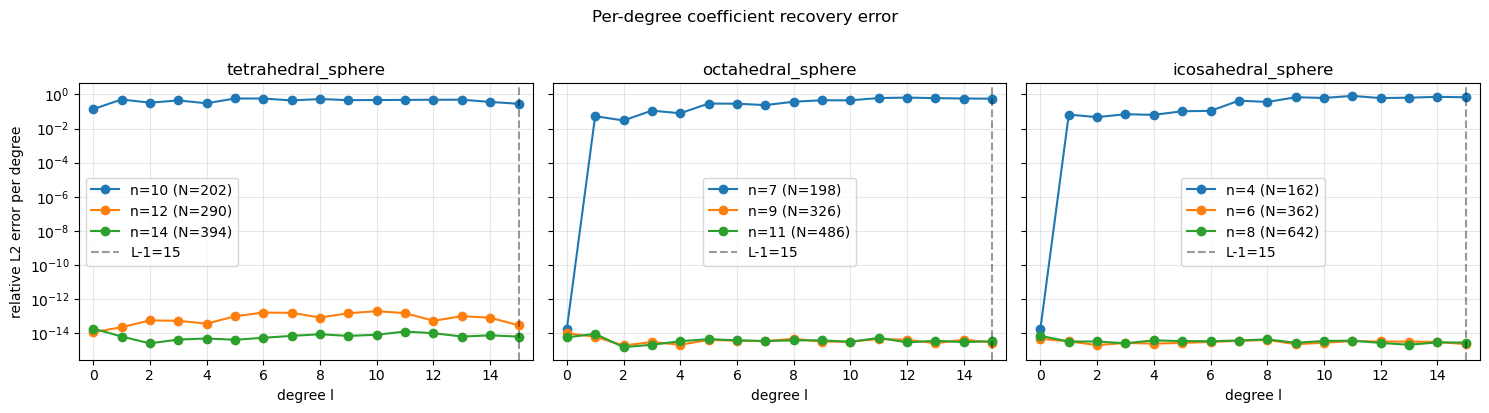

In [17]:
schemes = list(MESHES.keys())
max_deg = max(len(r["per_degree"]) for r in results)

fig, axes = plt.subplots(1, len(schemes), figsize=(5 * len(schemes), 4), sharex=True, sharey=True)
if len(schemes) == 1:
    axes = [axes]

for ax, scheme in zip(axes, schemes):
    scheme_results = [r for r in results if r["mesh_name"] == scheme]
    for r in scheme_results:
        ax.semilogy(np.arange(len(r["per_degree"])), r["per_degree"],
                    marker="o", label=f"n={r['n']} (N={r['n_points']})")
    ax.axvline(L - 1, color="k", linestyle="--", alpha=0.4, label=f"L-1={L-1}")
    ax.set_xlim(-0.5, max_deg - 0.5)
    ax.set_title(f"{scheme}_sphere")
    ax.set_xlabel("degree l")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("relative L2 error per degree")
fig.suptitle("Per-degree coefficient recovery error", y=1.02)
plt.tight_layout()
plt.show()

The above plots show the relative error per degree for each of the grid cases per scheme. This mostly drives a similar conclusion to the "Absolute Error per Mode" plot.

Undersampled grids have a high error in coefficients. In this, we can see the higher error of the critically sampled tetrahedral grids as compared to the other schemes. 

## Summary

In this notebook, we conducted an investigation for undersampled, critically sampled and oversampled grids for the polyhedral schemes (tetrahedral, octahedral and icosahedral).

The critically sampled grids for the octahedral and icosahedral casses reconstructed the ground-truth function to numerical precision. The tetrahedral scheme, on the other hand, while still relatively accurate, had a higher error in reconstruction. Although this might be associated to the sample points being closer to the number of coefficients (256) for the signal (290 for the tetrahedral vs 326 and 362 for the octahedral and icosahedral schemes respectively).

## Comparison with Classical Grids

The main advantage of using the classical grids is the computational speed enabled by Fast Fourier Transform algorithms. In the experiment, computation was not an issue for the polyhedral grids especially for a relatively smaller bandlimit. For a next step, it would be interesting to compare computational speed for signals with a larger degree (L > 1000).

The number of sample points needed to fully reconstruct a signal with degree 16 for each grid is summarised as follows:

| Scheme | Number of Sample Points |
|---|---:|
| Driscoll-Healy | 992 |
| Gauss-Legendre | 496 |
| McEwen-Wiaux | 496 |
| Tetrahedral | 290 |
| Octahedral | 326 |
| Icosahedral | 362 |

For the polyhedral grids, we can reconstruct the signal with fewer points. Also, because we used an existing library to generate the mesh, meaning we are limited to that library's mesh generation algorithm. it may be possible to reduce these further using a more efficient sampling design. 